Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Import Libraries

In [13]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

Directory Setup

In [4]:
BASE = "/content/drive/MyDrive/Bioinformatics/"
DATA = BASE + "data/processed/clinvar_final_annotated.csv"
MODEL_DIR = BASE + "models/"
OUT_DIR = BASE + "outputs/final/"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

print("Loading dataset:", DATA)
df = pd.read_csv(DATA)
print(df.head())

Loading dataset: /content/drive/MyDrive/Bioinformatics/data/processed/clinvar_final_annotated.csv
  CHROM     POS REF         ALT         CLNSIG  \
0     1   69134   A           G  Likely_benign   
1     1  809284   T  TGGTCAATCA         Benign   
2     1  924518   G           C  Likely_benign   
3     1  925956   C           T  Likely_benign   
4     1  925969   C           T  Likely_benign   

                               GENEINFO  ORIGIN                   Effect  \
0                           OR4F5:79501       1         missense_variant   
1                   LINC01409:105378580       1  downstream_gene_variant   
2  SAMD11:148398|LOC107985728:107985728       1       synonymous_variant   
3                         SAMD11:148398       1       synonymous_variant   
4                         SAMD11:148398       1         missense_variant   

     Impact       GeneName          Gene_ID Feature_Type         Feature_ID  \
0  MODERATE          OR4F5  ENSG00000186092   transcript  ENST000

Feature Engineering

In [5]:
# Create ref and alt length
df["REF_len"] = df["REF"].astype(str).apply(len)
df["ALT_len"] = df["ALT"].astype(str).apply(len)

# Convert CLNSIG to binary
def make_target(val):
    return 1 if ("Pathogenic" in str(val)) else 0

df["target"] = df["CLNSIG"].apply(make_target)

# Clean categorical columns
cat_cols = ["CHROM", "Effect", "Impact", "Transcript_BioType"]
for col in cat_cols:
    df[col] = df[col].astype(str)

print(df["target"].value_counts())

target
0    1382666
1     208884
Name: count, dtype: int64


Select Final Feature Set

In [6]:
X = df[
    [
        "CHROM",
        "POS",
        "REF_len",
        "ALT_len",
        "Effect",
        "Impact",
        "Transcript_BioType"
    ]
]

y = df["target"]

X.head()

,CHROM,POS,REF_len,ALT_len,Effect,Impact,Transcript_BioType
0,1,69134,1,1,missense_variant,MODERATE,protein_coding
1,1,809284,1,10,downstream_gene_variant,MODIFIER,lincRNA
2,1,924518,1,1,synonymous_variant,LOW,protein_coding
3,1,925956,1,1,synonymous_variant,LOW,protein_coding
4,1,925969,1,1,missense_variant,MODERATE,protein_coding


Preprocessing for Categorical Features

In [7]:
cat_features = ["CHROM", "Effect", "Impact",
                "Transcript_BioType"]

num_features = ["POS", "REF_len", "ALT_len"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", "passthrough", num_features)
    ]
)

Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size :", len(X_test))

Train size: 1273240
Test size : 318310


Build Random Forest Model Pipeline

In [ ]:
rf_base = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    class_weight={0: 1.0, 1: 0.8},
    random_state=42,
    n_jobs=-1
)

pipeline_base = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", rf_base)
    ]
)

print("Pipeline created")

Pipeline created


Model Training

In [ ]:
pipeline_base.fit(X_train, y_train)

print("Baseline model trained.")

When want to load model and not train it

In [10]:
'''
model_path = "/content/drive/MyDrive/Bioinformatics/models/rf_ann_model.pkl"
model = joblib.load(model_path)

print("Model loaded successfully.")

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
'''

Accuracy : 0.9386604253714932
Precision: 0.7853991381079417
Recall   : 0.7328913038274649
F1 Score : 0.7582372679882616
ROC-AUC  : 0.9707672556237036

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.97      0.96    276533
           1       0.79      0.73      0.76     41777

    accuracy                           0.94    318310
   macro avg       0.87      0.85      0.86    318310
weighted avg       0.94      0.94      0.94    318310



BASELINE MODEL EVALUATION

In [1]:
y_pred = pipeline_base.predict(X_test)
y_prob = pipeline_base.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

NameError: name 'pipeline_base' is not defined

SAVE TRAINED MODEL

In [ ]:
model_path = MODEL_DIR + "rf_ann_model.pkl"
joblib.dump(pipeline_base, model_path)

print("Model saved to:", model_path)

CONFUSION MATRIX

<Figure size 600x600 with 0 Axes>

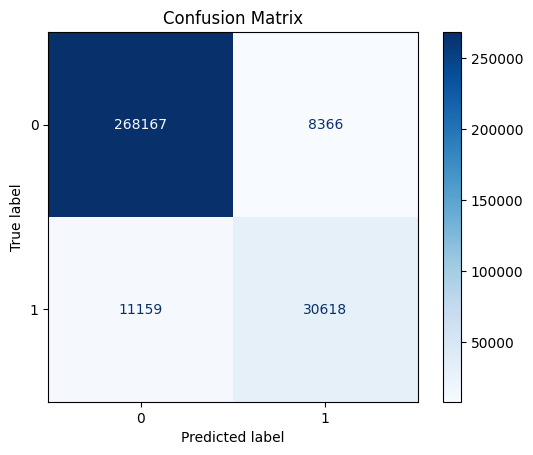

In [17]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

ROC CURVE

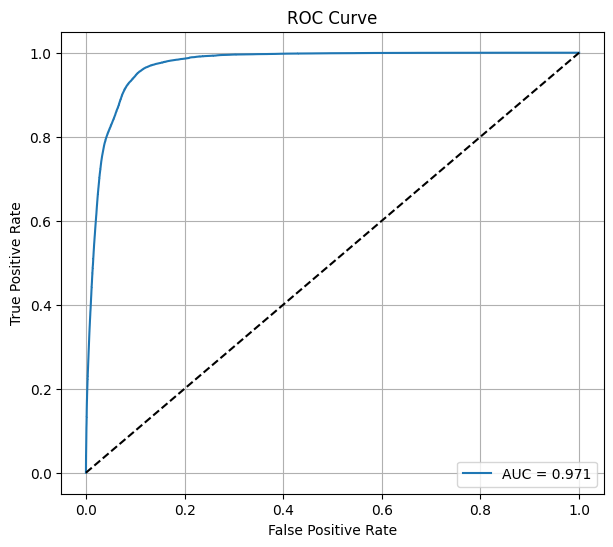

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "roc_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

FEATURE IMPORTANCE

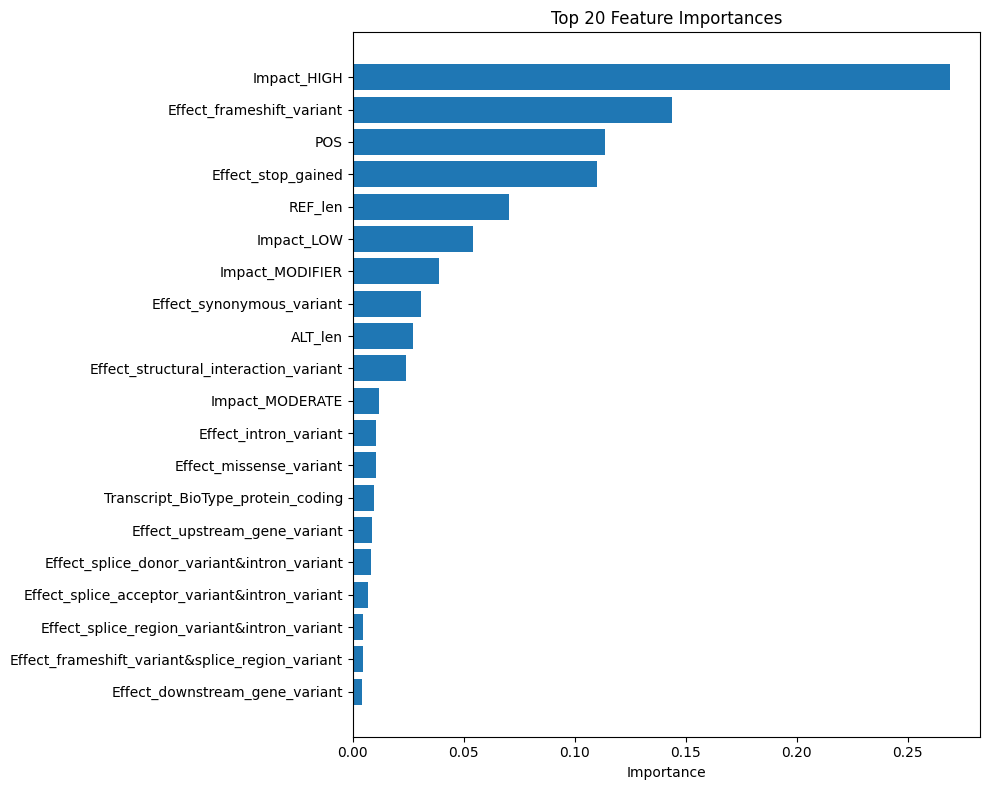

In [22]:
try:
    importances = model.named_steps["model"].feature_importances_
    ohe = model.named_steps["preprocess"].named_transformers_["cat"]
    cat_cols = ohe.get_feature_names_out(["CHROM", "Effect", "Impact", "Transcript_BioType"])
    num_cols = ["POS", "REF_len", "ALT_len"]
    feature_names = list(cat_cols) + num_cols

    # Sort features
    indices = np.argsort(importances)[-20:]  # Top 20
    plt.figure(figsize=(10, 8))
    plt.barh(np.array(feature_names)[indices], importances[indices])
    plt.title("Top 20 Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "feature_importance.png"), dpi=300, bbox_inches="tight")
    plt.show()

except Exception as e:
    print("\nFeature importance could not be extracted (likely non-RF model or pipeline issue).")
    print("Error:", e)